In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkExpansionPy.folds as nf
import networkExpansionPy.lib as ne
import csv
import ast
import json
import requests

In [2]:
def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]

    
    return valid_keys, data1, data2

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts', x_range = None):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if not x_range is None:
        plt.xlim([x_range[0], x_range[1]])
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()
    
def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('scatter.png')
    plt.show()
    
def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

def rnWith(xgroup, rn2rules):
    rnWithX = []
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if xgroup in rule:
                rnWithX.append(reaction)
                break
    return rnWithX
    
def get_reactions_for_compound(compound_id):
    response = requests.get(f'https://rest.kegg.jp/link/reaction/{compound_id}')
    lines = response.text.split('\n')
    
    reactions = []
    for line in lines:
        try:
            reactions.append(line.split('\t')[1][3:])
        except:
            pass
    return reactions

In [4]:
rn2eqn_SI = csv2dict('../data/assets/rn2eqn_SI.csv')
cpd2rn = csv2dict('../data/assets/cpd2rn.csv')
zpd2name = csv2dict('../data/assets/zpd2name.csv')
cpd2name = csv2dict('../data/assets/cpd2nameShort.csv')
rn2reversible = csv2dict('../data/assets/rn2reversible.csv')

In [5]:
x2ns = csv2dict('../data/assets/xgroup2/xgroup2networkSize.csv')
rn2rules = pd.read_pickle('../data/assets/rn2rules.20230224.pkl')
x2rn = {}
for xgroup in x2ns.keys():
    x2rn[xgroup] = rnWith(xgroup, rn2rules)

# X2rn_required

In [5]:
x2rn_required = {x:[] for x in x2rn.keys()}

for x, rns in x2rn.items():
    for rn in rns:
        required = 0
        for rule in rn2rules[rn]:
            if x in rule:  # rule contains the fold
                required += 1
        if required == len(rn2rules[rn]):  # all rules require this fold
            x2rn_required[x].append(rn)

# batm

In [3]:
# best at the moment
batm = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-32-36_no_look_ahead_rules_ignore_versions_3141.pkl.gz')

In [22]:
folditer2rns = {}
for rn, i in batm.rns_folditer.items():
    if i not in folditer2rns.keys():
        folditer2rns[i] = []
    folditer2rns[i].append(rn)

In [23]:
folditer2cpds = {}
for cpd, i in batm.cpds_folditer.items():
    if i not in folditer2cpds.keys():
        folditer2cpds[i] = []
    folditer2cpds[i].append(cpd)

In [24]:
folditer2folds = {}
for fold, i in batm.folds_folditer.items():
    if i not in folditer2folds.keys():
        folditer2folds[i] = []
    folditer2folds[i].append(fold)

In [25]:
cumiter2rns = {}
for rn, i in batm.rns_cumiter.items():
    if i not in cumiter2rns.keys():
        cumiter2rns[i] = []
    cumiter2rns[i].append(rn)

In [26]:
cumiter2cpds = {}
for cpd, i in batm.cpds_cumiter.items():
    if i not in cumiter2cpds.keys():
        cumiter2cpds[i] = []
    cumiter2cpds[i].append(cpd)

In [27]:
cumiter2folds = {}
for fold, i in batm.folds_cumiter.items():
    if i not in cumiter2folds.keys():
        cumiter2folds[i] = []
    cumiter2folds[i].append(fold)

In [28]:
print(len(folditer2rns))
print(len(folditer2cpds))
print(len(folditer2folds))

38
28
398


In [29]:
# fold injections with no cpd discovery
len(set(folditer2folds.keys()) - set(folditer2cpds.keys()))

370

In [30]:
# cpd discovery with no fold injection
len(set(folditer2cpds.keys()) - set(folditer2folds.keys()))

0

In [31]:
print(len(cumiter2rns))
print(len(cumiter2cpds))
print(len(cumiter2folds))

150
138
398


In [32]:
# fold injections with no cpd discovery
len(set(cumiter2folds.keys()) - set(cumiter2cpds.keys()))

370

In [33]:
# cpd discovery with no fold injection
len(set(cumiter2cpds.keys()) - set(cumiter2folds.keys()))

110

In [34]:
# rn discovery with no cpd discovery (alternative pathway?)
len(set(cumiter2rns.keys()) - set(cumiter2cpds.keys()))

13

In [35]:
# cpd discovery with no rn discovery
len(set(cumiter2cpds.keys()) - set(cumiter2rns.keys()))

1

In [36]:
for cumi in sorted(set(cumiter2cpds.keys()) - set(cumiter2rns.keys())):
    print(cumi, {k for k,v in batm.cpds_cumiter.items() if v==cumi})

0 {'C00288', 'C00150', 'Z00029', 'C01330', 'C00183', 'C00037', 'C00311', 'C00161', 'C14819', 'C00122', 'C00305', 'Z00055', 'C00283', 'C01335', 'C00282', 'C00041', 'C00407', 'C00209', 'C22155', 'C06232', 'Z00063', 'C00205', 'C00022', 'Z00033', 'C00071', 'Z00060', 'Z00053', 'C00417', 'Z00062', 'C00025', 'C00238', 'C00188', 'C00028', 'C20679', 'C00065', 'C19609', 'Z00064', 'C00149', 'C00011', 'C00034', 'C00160', 'C00030', 'Z00015', 'C01528', 'C00123', 'C14818', 'C00048', 'Z00006', 'C00058', 'C00038', 'C00042', 'C00383', 'C01732', 'C00049', 'C00033', 'Z00054', 'C00070', 'C00036', 'C00001', 'C19806', 'C00050', 'C00175', 'C01127', 'Z00020', 'Z00001', 'C00069', 'C00026', 'C00012', 'C00023', 'Z00002', 'Z00067', 'Z00070', 'Z00034', 'Z00030', 'Z00069', 'C00080', 'C00148', 'C17023', 'C00009', 'C00014'}


In [37]:
for cumi in range(18, 22):
    print(cumi, {k for k,v in batm.rns_cumiter.items() if v==cumi})

18 set()
19 set()
20 set()
21 set()


In [23]:
for rn in {'R00996_v1'}:
    print(f"{rn}: {rn2eqn_SI[rn]}")

R00996_v1: C00109 + C00014 + Z00063 => C00188 + Z00063


In [24]:
for rn in {'R00995_v2', 'R00995_v1', 'R11098_v1', 'R00995_v3'}:
    print(f"{rn}: {rn2eqn_SI[rn]}")

R00995_v2: C00109 + C00011 + Z00029 => C06030 + Z00029
R11098_v1: C00109 + C00014 + Z00063 => C20905 + C00001 + Z00063
R00995_v1: C00109 + C00011 + Z00030 => C06030 + Z00030
R00995_v3: C00109 + C00011 + Z00069 => C06030 + Z00069


In [25]:
for rn in {'R08637', 'R11101_v1', 'R04269'}:
    print(f"{rn}: {rn2eqn_SI[rn]}")

R08637: C17234 + C00001 => C00109 + C00014
R04269: C06030 + C00025 => C03618 + C00026
R11101_v1: C20905 + Z00063 => C17234 + Z00063


In [26]:
for rn in cpd2rn['C00109']:
    print(batm.rns_cumiter[rn])
    print(rn, rn2eqn_SI[rn])

388
R00654_v1 C00409 + C00014 + C00109 + Z00035 => C00073 + C00001 + Z00035
851
R00993 C00109 + C00009 + C00007 => C02876 + C00011 + C00027
249
R00994_v1 C06032 + C00003 + Z00030 => C00109 + C00011 + C00004 + C00080 + Z00030
20
R00995_v1 C00109 + C00011 + Z00030 => C06030 + Z00030
20
R00995_v2 C00109 + C00011 + Z00029 => C06030 + Z00029
20
R00995_v3 C00109 + C00011 + Z00069 => C06030 + Z00069
19
R00996_v1 C00109 + C00014 + Z00063 => C00188 + Z00063
44
R00996_v2 C00109 + C00014 + Z00035 => C00188 + Z00035
45
R00997_v1 C00109 + C00014 + Z00035 => C01234 + C00001 + Z00035
262
R00998 C00024 + C00001 + C00109 => C02488 + C00010
88
R00999_v1 C01118 + C00001 + Z00035 => C00109 + C00042 + C00014 + Z00035
250
R01000 C00109 + C00004 + C00080 => C05984 + C00003
87
R01001_v1 C00097 + C00014 + C00109 + Z00035 => C02291 + C00001 + Z00035
407
R01199_v1 2C00138 + 2C00080 + C00100 + C00011 + Z00029 + Z00002 + Z00047 => 2C00139 + C00109 + C00010 + Z00029 + Z00002 + Z00047
87
R01283_v1 C00283 + C00014 + 

# X3997

In [27]:
batm.folds_cumiter['3997']

848

In [28]:
cumiter2rns[batm.folds_cumiter['3997']+1]  # 848 + 1 = 849

['R03877', 'RZ_305']

In [29]:
x2rn['3997']

['R03877']

# X146

In [30]:
batm.folds_cumiter['146']  # X146 is injected after X3997

867

In [31]:
set(x2rn['146']) & set(cumiter2rns[batm.folds_cumiter['146']+1])

set()

In [32]:
set(x2rn['146']) & set(cumiter2rns[batm.folds_cumiter['146']])
# fold injection coincides with rn utilization

{'R00031_v1',
 'R00045_v1',
 'R00058_v1',
 'R00080_v1',
 'R00731_v1',
 'R02078_v1',
 'R02363_v1',
 'R02383_v1',
 'R02950_v1',
 'R07224_v1',
 'R07225_v1',
 'R08005_v1',
 'R08008_v1',
 'R08009_v1',
 'R08010_v1'}

In [33]:
# check the cumiter immediately after X146 injection
set(cumiter2rns[batm.folds_cumiter['146']+1])
#  none of these are rn catalyzed by X146!

{'QUIN_SYN2', 'R02962', 'R08011', 'RZ_179', 'RZ_195', 'RZ_199', 'RZ_205'}

In [34]:
print(set(cumiter2rns[batm.folds_cumiter['146']+1]))

{'R08011', 'R02962', 'RZ_199', 'RZ_195', 'RZ_179', 'RZ_205', 'QUIN_SYN2'}


# function to visualize fold injection => reaction discovery

In [35]:
fold2recruit = {}

In [36]:
cumiter2rns_Num = {i: len(cumiter2rns[i]) for i in cumiter2rns.keys()}

# full rn discovery plot
cumiter2rnNumFull = {}
for i in range(0, max(cumiter2rns_Num.keys())):
    if i not in cumiter2rns_Num.keys():
        cumiter2rnNumFull[i] = 0
    else:
        cumiter2rnNumFull[i] = cumiter2rns_Num[i]

In [37]:
list(batm.folds_cumiter.keys())[2:]

['2002',
 '1',
 '2487',
 '2006',
 '246',
 '2003',
 '218',
 '2007',
 '7525',
 '304',
 '12',
 '11',
 '10',
 '109',
 '210',
 '7515',
 '279',
 '7577',
 '3016',
 '281',
 '7542',
 '7528',
 '331',
 '2011',
 '301',
 '7572',
 '282',
 '206',
 '325',
 '805',
 '7527',
 '62',
 '7529',
 '180',
 '3691',
 '4126',
 '7560',
 '7512',
 '7518',
 '7579',
 '70',
 '297',
 '286',
 '205',
 '7554',
 '4002',
 '2004',
 '7580',
 '315',
 '307',
 '7561',
 '5104',
 '212',
 '7517',
 '7571',
 '5',
 '7510',
 '2',
 '387',
 '7567',
 '247',
 '208',
 '7516',
 '7574',
 '2484',
 '185',
 '103',
 '2005',
 '64',
 '7573',
 '2493',
 '708',
 '7552',
 '328',
 '7520',
 '283',
 '611',
 '810',
 '302',
 '7543',
 '211',
 '285',
 '7541',
 '3847',
 '164',
 '3651',
 '4021',
 '298',
 '2498',
 '4081',
 '2485',
 '632',
 '149',
 '7523',
 '4045',
 '4020',
 '355',
 '4178',
 '108',
 '7587',
 '4018',
 '812',
 '101',
 '7507',
 '7546',
 '144',
 '3374',
 '7586',
 '4044',
 '4017',
 '4952',
 '602',
 '4953',
 '7524',
 '236',
 '221',
 '129',
 '159',
 '131'

In [38]:
# fold = '3997'

for fold in list(batm.folds_cumiter.keys())[2:]:
    cumiter2rns_fold = {}
    for rn in x2rn_required[fold]:  # ignore reactions that don't need this fold
#     for rn in x2rn[fold]:  # look at all reactions
        i = batm.rns_cumiter.get(rn, None)
        if not i is None:
            if i not in cumiter2rns_fold.keys():
                cumiter2rns_fold[i] = [rn]
            else:
                cumiter2rns_fold[i].append(rn)

    # print(cumiter2rns_fold)
    cumiter2rns_fold_Num = {i:len(rns) for i, rns in cumiter2rns_fold.items()}
    # print(cumiter2rns_fold_Num)

    # plot for particular fold
    x = []
    for i in range(max(batm.rns_cumiter.values())):
        x.append(cumiter2rns_fold_Num.get(i, 0))

    print(fold)
    try:
        fold2recruit[fold] = [x[batm.folds_cumiter[fold]-1], x[batm.folds_cumiter[fold]], x[batm.folds_cumiter[fold]+1]]
    except:
        fold2recruit[fold] = [0, 0, 0]  # deal with the last folds: out of index


# plot the figure

# plt.figure(figsize=(30, 10))
# plt.plot(cumiter2rnNumFull.values(), color='green')
# plt.plot(x, color='red')
# plt.axvline(x=batm.folds_cumiter[fold], color='red', linestyle='--', alpha=0.3)  # Add vertical line
# plt.xlim([0, max(cumiter2rns_Num.keys())])

# # plt.savefig(f'cumiter2rn_discovery_{fold}.png', dpi=300, bbox_inches='tight')
# plt.show()

# print(f"X{fold}:")
# print(f"      {batm.folds_cumiter[fold]} = cumiter@injection")

2002
1
2487
2006
246
2003
218
2007
7525
304
12
11
10
109
210
7515
279
7577
3016
281
7542
7528
331
2011
301
7572
282
206
325
805
7527
62
7529
180
3691
4126
7560
7512
7518
7579
70
297
286
205
7554
4002
2004
7580
315
307
7561
5104
212
7517
7571
5
7510
2
387
7567
247
208
7516
7574
2484
185
103
2005
64
7573
2493
708
7552
328
7520
283
611
810
302
7543
211
285
7541
3847
164
3651
4021
298
2498
4081
2485
632
149
7523
4045
4020
355
4178
108
7587
4018
812
101
7507
7546
144
3374
7586
4044
4017
4952
602
4953
7524
236
221
129
159
131
7531
213
2486
7581
223
7504
222
3692
4004
220
65
230
503
276
219
7558
321
239
323
7522
7501
2492
244
7514
3883
266
5084
150
217
3699
6094
7588
327
868
7564
207
7509
7589
300
277
187
133
3688
376
177
314
141
7534
3754
601
312
4093
209
7500
375
4279
371
330
136
296
4995
4019
3257
172
3264
231
873
232
629
275
3599
6113
6058
106
147
189
377
7553
5038
7550
1137
4262
7536
270
3117
3896
243
3654
3086
830
7539
3292
7549
842
154
4237
7562
305
4022
1055
107
4011
7584
235
633
2496

In [39]:
fold2recruit['146']

[0, 15, 0]

In [40]:
fold2recruit['3997']

[0, 0, 1]

In [41]:
# no cases where first number is positive

for fold in fold2recruit.keys():
    if fold2recruit[fold][0] > 0:
        print(fold, fold2recruit[fold])

In [42]:
count = 0
count2 = 0
count3 = 0

for fold in fold2recruit.keys():
    print(fold, fold2recruit[fold], batm.folds_cumiter[fold])
    if fold2recruit[fold][1] == 0:
        count += 1
        
        if fold2recruit[fold][2] > 0:  # recruitment right after
            count2 += 1
    else:
        count3 += 1

2002 [0, 5, 4] 3
1 [0, 0, 13] 7
2487 [0, 0, 7] 11
2006 [0, 0, 0] 15
246 [0, 2, 3] 16
2003 [0, 0, 1] 18
218 [0, 0, 4] 22
2007 [0, 6, 4] 40
7525 [0, 0, 4] 49
304 [0, 1, 6] 51
12 [0, 7, 3] 58
11 [0, 2, 6] 60
10 [0, 2, 2] 63
109 [0, 5, 4] 65
210 [0, 0, 3] 69
7515 [0, 0, 0] 73
279 [0, 4, 0] 77
7577 [0, 6, 2] 78
3016 [0, 5, 18] 86
281 [0, 0, 8] 92
7542 [0, 1, 3] 96
7528 [0, 2, 1] 99
331 [0, 3, 1] 101
2011 [0, 0, 0] 103
301 [0, 0, 0] 107
7572 [0, 0, 0] 108
282 [0, 0, 1] 109
206 [0, 1, 1] 116
325 [0, 0, 3] 119
805 [0, 0, 0] 123
7527 [0, 0, 0] 124
62 [0, 0, 0] 125
7529 [0, 0, 0] 126
180 [0, 0, 0] 127
3691 [0, 2, 0] 128
4126 [0, 0, 0] 129
7560 [0, 0, 3] 130
7512 [0, 1, 0] 134
7518 [0, 0, 0] 135
7579 [0, 0, 3] 136
70 [0, 2, 0] 138
297 [0, 3, 0] 139
286 [0, 1, 1] 140
205 [0, 3, 0] 142
7554 [0, 0, 0] 147
4002 [0, 3, 0] 148
2004 [0, 0, 0] 149
7580 [0, 0, 0] 150
315 [0, 2, 1] 151
307 [0, 0, 2] 153
7561 [0, 0, 2] 155
5104 [0, 0, 0] 158
212 [0, 0, 0] 159
7517 [0, 2, 0] 160
7571 [0, 0, 0] 161
5 [0, 0, 2

In [43]:
count # all cases where there's no 'REQUIRED' rn discovery at fold injection

189

In [44]:
count2  # cases like X3997, where REQUIRED rns are discovered AFTER fold injection

77

In [45]:
count3 # cases like X146, where REQUIRED rns are discovered WITH fold injection

208

# sanity check: X146

In [46]:
batm.folds_cumiter['146']

867

In [47]:
# folds

for cumi in range(865,870):
    print(cumi, {k for k,v in batm.folds_cumiter.items() if v==cumi})

865 set()
866 set()
867 {'146'}
868 set()
869 set()


In [48]:
# cpd

for cumi in range(865,870):
    print(cumi, {k for k,v in batm.cpds_cumiter.items() if v==cumi})

865 {'C11135', 'C03852', 'C12525', 'C05140', 'C11136'}
866 set()
867 {'C02351', 'C08576', 'C16409', 'C16828', 'C16410', 'C00822', 'C08577', 'C03861'}
868 {'C05604', 'C17935'}
869 {'C17751', 'C01693', 'C05578'}


In [49]:
for rn in 'R00031_v1', 'R00058_v1', 'R07224_v1', 'R00080_v1', 'R08010_v1', 'R00731_v1', 'R07225_v1', 'R08009_v1', 'R02950_v1', 'R08008_v1', 'R02078_v1', 'R02383_v1', 'R08005_v1', 'R02363_v1', 'R00045_v1':
    print(rn, rn2rules[rn])

R00031_v1 {frozenset({'146', '10'})}
R00058_v1 {frozenset({'146'}), frozenset({'146', '10'})}
R07224_v1 {frozenset({'146', '10'})}
R00080_v1 {frozenset({'146', '10'})}
R08010_v1 {frozenset({'146', '10'})}
R00731_v1 {frozenset({'146'})}
R07225_v1 {frozenset({'146', '10'})}
R08009_v1 {frozenset({'146', '10'})}
R02950_v1 {frozenset({'146'})}
R08008_v1 {frozenset({'146', '10'})}
R02078_v1 {frozenset({'146'}), frozenset({'146', '10'})}
R02383_v1 {frozenset({'146'})}
R08005_v1 {frozenset({'146', '10'})}
R02363_v1 {frozenset({'146'})}
R00045_v1 {frozenset({'146', '10'})}


In [50]:
# rn

for cumi in range(865,870):
    print(cumi, {k for k,v in batm.rns_cumiter.items() if v==cumi})

865 {'R03407', 'R02476', 'R09956', 'R02499', 'R03406', 'R02498', 'R04309', 'R02477', 'R02497', 'R02502_v1', 'R04310'}
866 {'R04330', 'R02478_v1', 'R08963', 'R04344', 'R04678', 'R04352_v1'}
867 {'R00080_v1', 'R00031_v1', 'R07224_v1', 'R08009_v1', 'R08005_v1', 'R02078_v1', 'R02383_v1', 'R02363_v1', 'R08010_v1', 'R00045_v1', 'R02950_v1', 'R07225_v1', 'R00731_v1', 'R08008_v1', 'R00058_v1'}
868 {'R08011', 'R02962', 'RZ_199', 'RZ_195', 'RZ_179', 'RZ_205', 'QUIN_SYN2'}
869 {'R03672', 'R08848', 'R04885'}


In [51]:
for rn in cpd2rn['C00822']:
    print(batm.rns_cumiter[rn])
    print(rn, rn2eqn_SI[rn], rn2reversible[rn])

867
R00045_v1 2C00355 + C00007 + Z00070 + 2C00355 + C00007 + Z00070 + Z00046 => 2C00822 + 2C00001 + Z00070 + 2C00822 + 2C00001 + Z00070 + Z00046 False
867
R02078_v1 C00355 + C00082 + C00007 + Z00070 + C00355 + C00082 + C00007 + Z00070 + Z00046 => C00822 + C00355 + C00001 + Z00070 + C00822 + C00355 + C00001 + Z00070 + Z00046 False
868
R02962 C00822 => C05604 False
869
R03672 C05604 + C00822 => C01693 + C00355 False
869
R08848 C17935 => C00822 + C00097 True
868
RZ_199 C00822 => Z00022 False


In [52]:
for rn in {'RZ_195', 'QUIN_SYN2', 'R02962', 'RZ_205', 'RZ_199', 'RZ_179', 'R08011'}:
    print(rn, rn2rules.get(rn, 0))

R08011 0
RZ_199 0
RZ_195 0
QUIN_SYN2 0
RZ_179 0
RZ_205 0
R02962 {frozenset({'spontaneous'})}


# sanity check: X3997

In [53]:
batm.rns_cumiter

{'RZ_492': 1,
 'R04177': 2,
 'R03693': 2,
 'R00628': 2,
 'RZ_340': 1,
 'RZ_502': 1,
 'R00477': 2,
 'R00338_v1': 1,
 'R03266': 2,
 'R12185': 2,
 'R00219': 2,
 'R00347_v4': 2,
 'RZ_388': 1,
 'R03597': 1,
 'RZ_510': 1,
 'RZ_144': 1,
 'R00412': 1,
 'RZ_341': 1,
 'R01336': 2,
 'RZ_5': 1,
 'RZ_503': 1,
 'RZ_493': 1,
 'RZ_513': 1,
 'RZ_424': 1,
 'RZ_107': 1,
 'RZ_3': 1,
 'RZ_511': 1,
 'R00347_v1': 2,
 'R00476_v1': 1,
 'RZ_423': 1,
 'R08698': 2,
 'RZ_501': 1,
 'RZ_507': 1,
 'R00347_v3': 2,
 'R00493': 1,
 'RZ_508': 1,
 'RZ_106': 1,
 'R00218': 1,
 'R00263': 1,
 'RZ_515': 1,
 'RZ_273': 1,
 'RZ_514': 1,
 'R01854': 2,
 'R00363': 2,
 'RZ_481': 1,
 'R01339': 1,
 'R00268_v3': 2,
 'RZ_27': 1,
 'RZ_506': 1,
 'R07316': 2,
 'RZ_304': 1,
 'RZ_480': 1,
 'R00347_v2': 2,
 'R03694': 2,
 'R00430_gGTP_v1': 5,
 'R00471_v1': 4,
 'R00346': 5,
 'R00479_v1': 3,
 'R00217_v3': 3,
 'R00200_gATP_v1': 5,
 'R00217_v1': 3,
 'R00217_v2': 3,
 'R10283_v1': 4,
 'R00345_v2': 4,
 'RZ_383': 4,
 'R00320': 6,
 'R00430_gGTP_v2': 5,
 

In [54]:
rn2rules['R06469']

{frozenset({'109'})}

In [55]:
batm.folds_cumiter['109']

65

In [56]:
batm.rules_cumiter[('R06469', frozenset({'109'}))]

848

In [57]:
batm.cpds_cumiter['C01054']

851

In [58]:
batm.rns_cumiter['R06469']

852

In [59]:
batm.cpds_cumiter['C08616']

852

In [60]:
rn2rules['R06469']

{frozenset({'109'})}

In [61]:
# cumiter:

# compound (was produced as product)
# reaction (that produced the product cpd)
# rule (particular rule for that reaction)  *** caution: all rules used until next fold injection is logged to same cumiter!

"""in 1 step of ne, which give you the most new rules"""

'in 1 step of ne, which give you the most new rules'

In [62]:
# folds

for cumi in range(846,851):
    print(cumi, {k for k,v in batm.folds_cumiter.items() if v==cumi})

846 {'911'}
847 {'5039'}
848 {'3997'}
849 set()
850 set()


In [81]:
# cpd

for cumi in range(846,852):
    print(cumi, {k for k,v in batm.cpds_cumiter.items() if v==cumi})

846 set()
847 set()
848 {'C03516'}
849 {'C04536'}
850 {'C11831', 'C00007', 'C11829'}
851 {'C20701', 'C11501', 'C21411', 'C01054', 'C20631', 'C03004', 'C12457', 'C20996', 'C05856', 'C21348', 'C17203', 'C06455', 'C21758', 'C01215', 'C02372', 'C21330', 'C21081', 'C22354', 'C19938', 'C21723', 'C03196', 'C00530', 'C21943', 'C20994', 'C11830', 'C03230', 'C00547', 'C00704', 'C11990', 'C11996', 'C21890', 'C20997', 'C05811', 'C05834', 'C01163', 'C06732', 'C21263', 'C16360', 'C21893', 'C17953', 'C21978', 'C02892', 'C08591', 'C12623', 'C20850', 'C22166', 'C21825', 'C05852', 'C22146', 'C21251', 'C01993', 'C12145', 'C16355', 'C22300', 'C05842', 'C20695', 'C21065', 'C17262', 'C21894', 'C21886', 'C02106', 'C04366', 'C11954', 'C02923', 'C21623', 'C22012', 'C03574', 'C21256', 'C20231', 'C06098', 'C02779', 'C10784', 'C11631', 'C21620', 'C19892', 'C22169', 'C01133', 'C21795', 'C17237', 'C20254', 'C21827', 'C05658', 'C11527', 'C17255', 'C21459', 'C20310', 'C06178', 'C11962', 'C19081', 'C21903', 'C07084', 

In [64]:
# rn

for cumi in range(846,852):
    print(cumi, {k for k,v in batm.rns_cumiter.items() if v==cumi})

846 {'R09502_v1'}
847 set()
848 set()
849 {'R03877', 'RZ_305'}
850 {'R04237', 'RZ_308', 'R11494_v1', 'R11494_v2'}
851 {'R10790_v1', 'R03369_v1', 'R00993', 'R03568_v1', 'R07969_v1', 'R06154_v3', 'R08408_v1', 'R07214_v2', 'R02150_v2', 'R05334_v3', 'R02535_v1', 'R07965_v1', 'R07976_v1', 'R11015_v1', 'R12224_v1', 'R01769_v1', 'R00608_v1', 'R01022_v1', 'R07939_v1', 'R09077_v1', 'R11981_v1', 'R10160_v1', 'R05696_v1', 'R03246', 'R02521_v1', 'R12058_v1', 'R01709_v2', 'R07518_v1', 'R02076_v1', 'R02449_v1', 'R02529_v1', 'R08050_v1', 'R12076_v1', 'R02107_v2', 'R07973_v1', 'R08604', 'R00275_v1', 'R10920_v1', 'R06269_v2', 'R01151_v2', 'R02613_v1', 'R04085_v1', 'R00359_v2', 'R03566_v1', 'R00357_v1', 'R12547', 'R10107', 'R06398_v1', 'R11748_v1', 'R01469_v1', 'R05317_v1', 'R06786_v1', 'R02894_v1', 'R09784_v1', 'R01260', 'R01709_v1', 'R09076_v1', 'R05778_v1', 'R12226_v1', 'R08920', 'R03222_v1', 'R08607_v1', 'R02923_v1', 'R02445_v1', 'R11053_v1', 'R11119', 'R01710_v1', 'R11805_v1', 'R09935_v1', 'R07363_

In [80]:
for rn in [k for k,v in batm.rns_cumiter.items() if v==851]:
    print(rn, rn2eqn_SI[rn], rn2reversible[rn])

R04300_v3 C03758 + C00001 + C00007 + Z00035 + Z00022 + Z00030 + Z00054 => C04043 + C00014 + C00027 + Z00035 + Z00022 + Z00030 + Z00054 False
R07962_v1 C07480 + C00005 + C00080 + C00007 + Z00015 + Z00014 + Z00001 => C16353 + C00006 + C00067 + C00001 + Z00015 + Z00014 + Z00001 False
R01629_v1 C00230 + C00007 + C00004 + C00080 + Z00013 => C02814 + C00011 + C00003 + C00001 + Z00013 False
R09936 C00106 + C01847 + C00007 => C20231 + C00061 False
R00689_v2 C00079 + C00001 + C00007 + Z00014 + Z00019 => C00166 + C00014 + C00027 + Z00014 + Z00019 False
R06464_v1 2C00138 + 2C00080 + C11998 + C00007 + Z00025 + Z00010 => 2C00139 + C11999 + C00001 + Z00025 + Z00010 False
R07363_v1 C15606 + C00007 + Z00034 => C08276 + C00058 + C00237 + Z00034 False
R07665 C01467 + C00007 + C00004 + C00080 => C03351 + C00003 + C00001 False
R02515_v1 C05593 + C00007 + C00004 + C00080 + Z00013 => C00544 + C00003 + C00001 + Z00013 False
R00893_v1 C00097 + C00007 + Z00032 + Z00015 => C00606 + Z00032 + Z00015 False
R07172_

R10670_v1 C19714 + C00097 + C00005 + C00007 + C00080 + Z00010 => 2C00001 + C17237 + C00006 + Z00010 False
R11912_v1 C00398 + C00030 + C00007 + Z00025 + Z00010 => C21762 + C00028 + C00001 + Z00025 + Z00010 False
R06462_v1 2C00138 + 2C00080 + C11994 + C00007 + Z00025 + Z00010 => 2C00139 + C11995 + C00001 + Z00025 + Z00010 False
R12650_v1 C00407 + C00026 + C00007 + Z00015 + Z00004 => C22300 + C00042 + C00011 + Z00015 + Z00004 False
R08896_v1 C01743 + C00007 + Z00013 => C17583 + C00027 + Z00013 False
R10626_v1 2C00138 + 2C00080 + C11998 + C00007 + Z00025 + Z00010 => 2C00139 + C20739 + C00001 + Z00025 + Z00010 False
R10160_v1 C20406 + C00007 + Z00013 => C10784 + C00027 + Z00013 False
R07977_v1 C13747 + C00007 + C00001 + Z00015 + Z00013 + Z00031 + Z00001 + Z00019 => C16356 + C00027 + Z00015 + Z00013 + Z00031 + Z00001 + Z00019 False
R01184_v1 C00137 + C00007 + Z00015 => C00191 + C00001 + Z00015 False
R01151_v2 C00134 + C00007 + C00001 + Z00061 + Z00030 + Z00054 => C00555 + C00014 + C00027 + Z

In [65]:
# 'R03877': C02191  =>  C03516 

In [77]:
# rules

for cumi in range(846,859):
    print(cumi, {k for k,v in batm.rules_cumiter.items() if v==cumi})

846 {('R09502_v1', frozenset({'911'}))}
847 {('R00294_v1', frozenset({'5039'}))}
848 {('R11491_v1', frozenset({'1'})), ('R10989', frozenset({'7512'})), ('R06363_v1', frozenset({'223', '4019'})), ('R07055', frozenset({'149'})), ('R01710_v1', frozenset({'1', '2003'})), ('R00729_v1', frozenset({'244', '2003'})), ('R11394_v1', frozenset({'2007', '4002'})), ('R02457_v1', frozenset({'2003'})), ('R10415_v1', frozenset({'10'})), ('R06268_v2', frozenset({'2002'})), ('R11014', frozenset({'2003', '209'})), ('R07214_v2', frozenset({'10'})), ('R09782', frozenset({'5'})), ('R11962', frozenset({'2007'})), ('R10298', frozenset({'2002'})), ('R08764_v1', frozenset({'244', '2003'})), ('R08181', frozenset({'7579', '222', '11', '10'})), ('R12154_v1', frozenset({'149'})), ('R09981', frozenset({'spontaneous'})), ('R11168_v2', frozenset({'244', '231', '217', '325', '179'})), ('R04880_v1', frozenset({'2007', '4002', '236', '2003'})), ('R10290', frozenset({'7512'})), ('R02364_v1', frozenset({'236', '2003'})), (

In [67]:
# check: 
# new cpd, but no new rn

In [82]:
for rn in cpd2rn['C04536']:
    print(rn, rn2eqn_SI[rn], rn2reversible[rn])
    print(batm.rns_cumiter[rn])

R04237 C00021 + C04536 => C00019 + C03516 True
850
R06265_v1 C04536 + C00005 + C00080 + C00007 + Z00015 => C11829 + C00006 + C00001 + Z00015 False
851
R06268_v1 C11829 + C05198 + C00073 + Z00002 + Z00009 => C04536 + C00019 + C00001 + Z00002 + Z00009 True
851
R06268_v2 C11829 + C05198 + C00073 + Z00063 + Z00009 => C04536 + C00019 + C00001 + Z00063 + Z00009 True
851
R09503_vX 2C03313 + C00007 + Z00025 + Z00015 + C04536 + Z00030 + Z00055 => 2C00001 + 2C02059 + 4C00205 + Z00025 + Z00015 + C04536 + Z00030 + Z00055 True
851
R11494_v1 3C00019 + C04536 + C00001 + Z00002 + Z00009 => 3C05198 + 3C00001 + C11831 + Z00002 + Z00009 False
850
R11494_v2 3C00019 + C04536 + C00001 + Z00063 + Z00009 => 3C05198 + 3C00001 + C11831 + Z00063 + Z00009 False
850
RZ_308 C04536 => Z00029 False
850


In [83]:
batm.cpds_cumiter['Z00029']

0

In [68]:
for rn in cpd2rn['C11831']:
    print(rn, rn2eqn_SI[rn], rn2reversible[rn])
    print(batm.rns_cumiter[rn])

R06270_v1 C11831 + C05198 + C00073 + Z00002 + Z00009 => C11830 + C00019 + Z00002 + Z00009 True
852
R06270_v2 C11831 + C05198 + C00073 + Z00063 + Z00009 => C11830 + C00019 + Z00063 + Z00009 True
852
R06271 C02880 => 2C00080 + C11831 False
852
R06286 C11831 + C00005 + C00080 => C11832 + C00006 True
852
R06896 C02880 + C00006 => C11831 + C00005 + C00080 True
852
R11494_v1 3C00019 + C04536 + C00001 + Z00002 + Z00009 => 3C05198 + 3C00001 + C11831 + Z00002 + Z00009 False
850
R11494_v2 3C00019 + C04536 + C00001 + Z00063 + Z00009 => 3C05198 + 3C00001 + C11831 + Z00063 + Z00009 False
850
R11519_v1 2C00138 + 2C00080 + C11831 + Z00002 + Z00013 => 2C00139 + C02880 + Z00002 + Z00013 True
852


In [69]:
for rn in cpd2rn['C04536']:
    print(rn, rn2eqn_SI[rn], rn2reversible[rn])
    print(batm.rns_cumiter[rn])

R04237 C00021 + C04536 => C00019 + C03516 True
850
R06265_v1 C04536 + C00005 + C00080 + C00007 + Z00015 => C11829 + C00006 + C00001 + Z00015 False
851
R06268_v1 C11829 + C05198 + C00073 + Z00002 + Z00009 => C04536 + C00019 + C00001 + Z00002 + Z00009 True
851
R06268_v2 C11829 + C05198 + C00073 + Z00063 + Z00009 => C04536 + C00019 + C00001 + Z00063 + Z00009 True
851
R09503_vX 2C03313 + C00007 + Z00025 + Z00015 + C04536 + Z00030 + Z00055 => 2C00001 + 2C02059 + 4C00205 + Z00025 + Z00015 + C04536 + Z00030 + Z00055 True
851
R11494_v1 3C00019 + C04536 + C00001 + Z00002 + Z00009 => 3C05198 + 3C00001 + C11831 + Z00002 + Z00009 False
850
R11494_v2 3C00019 + C04536 + C00001 + Z00063 + Z00009 => 3C05198 + 3C00001 + C11831 + Z00063 + Z00009 False
850
RZ_308 C04536 => Z00029 False
850


In [92]:
zcpd2name = {}
for c, name in zpd2name.items():
    zcpd2name[c] = name
for c, name in cpd2name.items():
    zcpd2name[c] = name  

In [93]:
for rn in cpd2rn['C04536']:
    print([batm.rns_cumiter[rn]], rn, rn2eqn_SI[rn], rn2reversible[rn])
    if rn2eqn_SI.get(rn, '') != '':
        r, p = rn2eqn_SI[rn].split(' => ')[0].split(' + '), rn2eqn_SI[rn].split(' => ')[1].split(' + ')
        print('L------------')
        for c in r:
            print(batm.cpds_cumiter[c[-6:]], c[-6:], zcpd2name[c[-6:]])
        print('R------------')
        for c in p:
            print(batm.cpds_cumiter[c[-6:]], c[-6:], zcpd2name[c[-6:]])
        print('')
    else:
        print('')

[850] R04237 C00021 + C04536 => C00019 + C03516 True
L------------
245 C00021 S-Adenosyl-L-homocysteine
849 C04536 Magnesium protoporphyrin monomethyl ester
R------------
385 C00019 S-Adenosyl-L-methionine
848 C03516 Magnesium protoporphyrin

[851] R06265_v1 C04536 + C00005 + C00080 + C00007 + Z00015 => C11829 + C00006 + C00001 + Z00015 False
L------------
849 C04536 Magnesium protoporphyrin monomethyl ester
249 C00005 NADPH
0 C00080 H+
850 C00007 Oxygen
0 Z00015 Iron
R------------
850 C11829 13(1)-Hydroxy-magnesium-protoporphyrin IX 13-monomethyl ester
248 C00006 NADP+
0 C00001 H2O
0 Z00015 Iron

[851] R06268_v1 C11829 + C05198 + C00073 + Z00002 + Z00009 => C04536 + C00019 + C00001 + Z00002 + Z00009 True
L------------
850 C11829 13(1)-Hydroxy-magnesium-protoporphyrin IX 13-monomethyl ester
386 C05198 5'-Deoxyadenosine
386 C00073 L-Methionine
0 Z00002 4Fe4S
617 Z00009 Cobalamin
R------------
849 C04536 Magnesium protoporphyrin monomethyl ester
385 C00019 S-Adenosyl-L-methionine
0 C0000

In [70]:
rn2rules['R06268_v2']

{frozenset({'2002'})}

In [71]:
rn2eqn_SI['RZ_305']

'C03516 => Z00029'

In [72]:
rn2eqn_SI['RZ_308']

'C04536 => Z00029'

In [73]:
zpd2name['Z00029']

'Mg'

In [74]:
rn2eqn_SI['R09502_v1']

'2C00139 + 2C00080 + C00342 + Z00002 => 2C00138 + C00343 + Z00002'

In [75]:
rn2rules['R09502_v1']

{frozenset({'911'})}

In [76]:
rn2eqn_SI['R04237']

'C00021 + C04536 => C00019 + C03516'

# cumiter fixed run

In [8]:
result = pd.read_pickle('../runs/2024-04-25_11-00-45_no_look_ahead_rules_ignore_versions_3141_cumiter_fix.pkl.gz')

In [9]:
folditer2cpd = {}
for c, order in result.cpds_folditer.items():
    if order not in folditer2cpd.keys():
        folditer2cpd[order] = [c]
    else:
        folditer2cpd[order].append(c)
print(len(folditer2cpd))

folditer2cpdNum = {}
for fold in folditer2cpd.keys():
    folditer2cpdNum[fold] = len(folditer2cpd[fold])

folditer2cpdNumFull = {}
for i in range(0, max(folditer2cpd.keys())):
    if i not in folditer2cpdNum.keys():
        folditer2cpdNumFull[i] = 0
    else:
        folditer2cpdNumFull[i] = folditer2cpdNum[i]

173


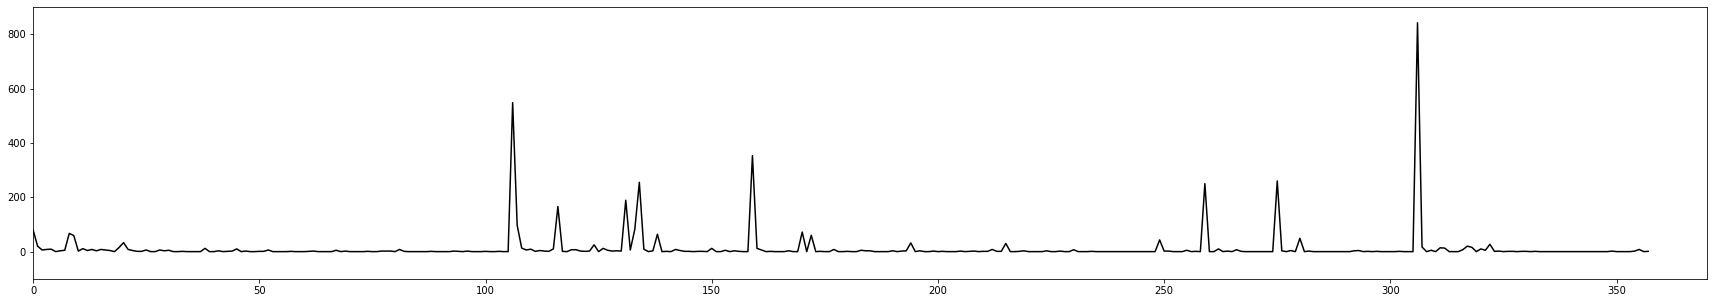

In [10]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# sns.rugplot(batm.folds_folditer.values(), height=0.04)
# sns.rugplot(multiple, height=0.04, color='blue')  # double fold injection
# sns.rugplot([368], height=0.08, color='#020079')  # triple fold injection

plt.xlim([0, 370])
plt.ylim([-100, 900])
# plt.savefig('3B_cpds.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
batm.iteration, batm.iteration_cum

NameError: name 'batm' is not defined

In [9]:
result.iteration, result.iteration_cum

(371, 891)

In [5]:
result.folds_cumiter['3997']

749

In [15]:
for cumi in range(746, 752):
    print(cumi, {k for k,v in result.folds_cumiter.items() if v==cumi})

746 {'3294'}
747 {'911'}
748 {'5039'}
749 {'3997'}
750 set()
751 set()


In [14]:
for cumi in range(746, 752):
    print(cumi, {k for k,v in result.cpds_cumiter.items() if v==cumi})

746 set()
747 set()
748 set()
749 {'C03516'}
750 {'C04536'}
751 {'C11831', 'C11829', 'C00007'}


In [16]:
for cumi in range(746, 752):
    print(cumi, {k for k,v in result.rns_cumiter.items() if v==cumi})

746 set()
747 {'R09502_v1'}
748 set()
749 {'R03877'}
750 {'RZ_305', 'R04237'}
751 {'R11494_v1', 'R06268_v2', 'RZ_308', 'R06268_v1', 'R09503_vX', 'R11494_v2'}


# check if I correctly copied harrison's pull request

In [22]:
result2 = pd.read_pickle('../runs/2024-06-17_19-39-53.pkl.gz')

In [13]:
result.iteration, result.iteration_cum

(371, 891)

In [23]:
result2.iteration, result2.iteration_cum

(369, 868)

In [16]:
batm.iteration, batm.iteration_cum

(371, 999)

In [25]:
result2.folds_cumiter['3997']

723

In [27]:
for cumi in range(720, 726):
    print(cumi, {k for k,v in result2.folds_cumiter.items() if v==cumi})

720 {'132'}
721 set()
722 {'3294'}
723 {'3997'}
724 set()
725 set()


In [28]:
for cumi in range(720, 726):
    print(cumi, {k for k,v in result2.cpds_cumiter.items() if v==cumi})

720 {'C03688'}
721 set()
722 set()
723 {'C03516'}
724 {'C04536'}
725 {'C00007', 'C11831', 'C11829'}


In [29]:
for cumi in range(720, 726):
    print(cumi, {k for k,v in result2.rns_cumiter.items() if v==cumi})

720 {'RZ_517'}
721 {'R01625_v1', 'R01623_v1', 'R10706_v1'}
722 set()
723 {'R03877'}
724 {'R04237', 'RZ_305'}
725 {'R06268_v1', 'R11494_v1', 'R11494_v2', 'R09503_vX', 'RZ_308', 'R06268_v2'}


In [ ]:
# worked!

In [1]:
result2

NameError: name 'result2' is not defined